<a href="https://colab.research.google.com/github/ahm-gondal/week6-advanced-nlp/blob/main/notebooks/week6_advanced_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape: (2225, 2)
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


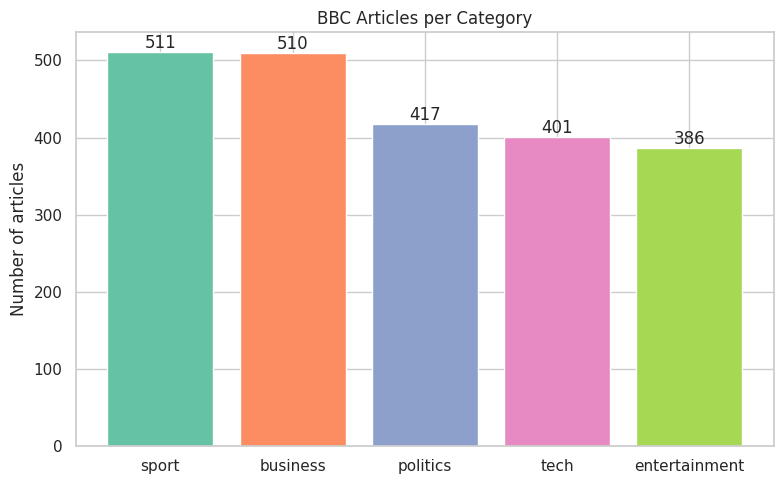

In [1]:
!pip -q install sentence-transformers >/dev/null 2>&1
!python -m spacy download en_core_web_sm -q >/dev/null 2>&1
import re, os, io, warnings, collections, urllib.request
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
u = 'https://raw.githubusercontent.com/suraj-deshmukh/BBC-Dataset-News-Classification/master/dataset/dataset.csv'
raw = urllib.request.urlopen(urllib.request.Request(u, headers={'User-Agent': 'Mozilla/5.0'}), timeout=30).read()
df = pd.read_csv(io.BytesIO(raw), encoding='latin-1').rename(columns={'news': 'text', 'type': 'category'})
df = df[['category', 'text']].dropna().reset_index(drop=True)
counts = df['category'].value_counts()
print('Shape:', df.shape)
print(counts)
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values, color=sns.color_palette('Set2', len(counts)))
ax.bar_label(bars)
ax.set_title('BBC Articles per Category')
ax.set_ylabel('Number of articles')
plt.tight_layout()
plt.savefig('category_distribution.png', dpi=110, bbox_inches='tight')
plt.show()

PERSON     10391
ORG         9265
DATE        7179
GPE         6488
NORP        2420
MONEY        886
LOC          490
EVENT        432
FAC          373
PRODUCT      267
dtype: int64


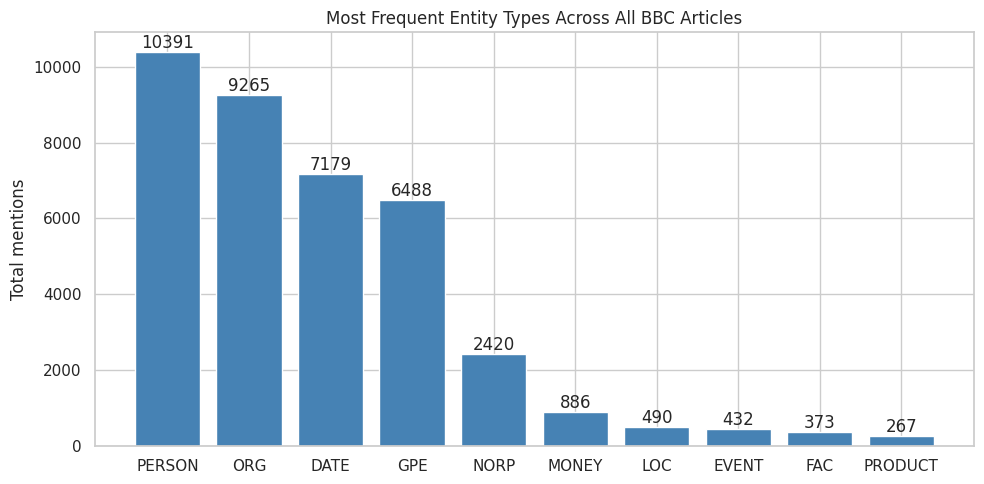

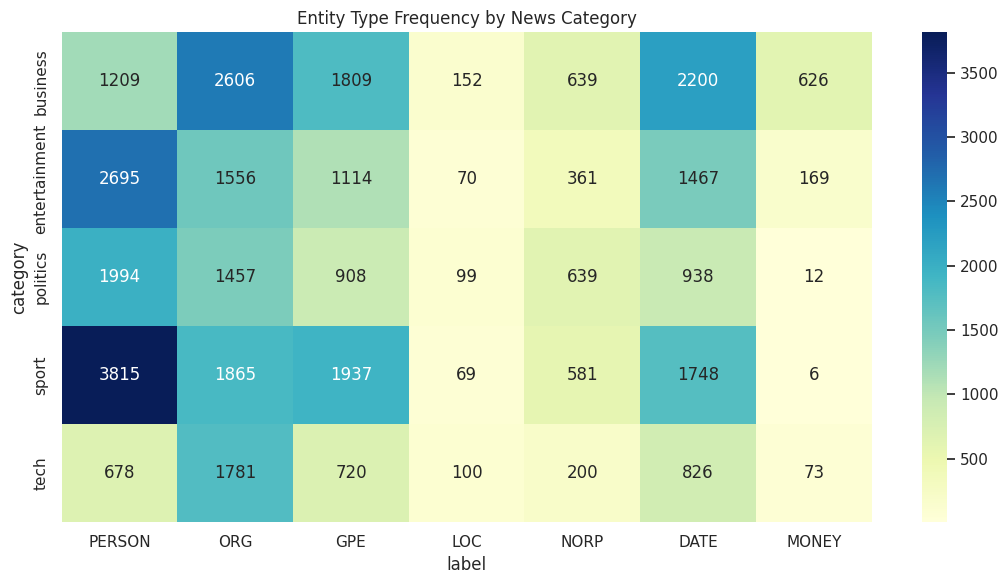

In [2]:

import spacy
nlp = spacy.load('en_core_web_sm', disable=['parser', 'lemmatizer', 'tagger', 'attribute_ruler'])
texts = df['text'].str.slice(0, 1000).tolist()
ENT_TYPES = {'PERSON', 'ORG', 'GPE', 'LOC', 'NORP', 'FAC', 'PRODUCT', 'EVENT', 'DATE', 'MONEY'}
doc_entities = []
for doc in nlp.pipe(texts, batch_size=64):
    doc_entities.append([(e.text.strip(), e.label_) for e in doc.ents if e.label_ in ENT_TYPES])
df['entities'] = doc_entities
label_counts = collections.Counter(lbl for ents in doc_entities for _, lbl in ents)
lc = pd.Series(label_counts).sort_values(ascending=False)
print(lc)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(lc.index, lc.values, color='steelblue')
ax.bar_label(bars)
ax.set_title('Most Frequent Entity Types Across All BBC Articles')
ax.set_ylabel('Total mentions')
plt.tight_layout()
plt.savefig('entity_type_frequency.png', dpi=110, bbox_inches='tight')
plt.show()
rows = []
for cat, ents in zip(df['category'], doc_entities):
    for _, lbl in ents:
        rows.append((cat, lbl))
ent_df = pd.DataFrame(rows, columns=['category', 'label'])
pivot = ent_df.pivot_table(index='category', columns='label', aggfunc=len, fill_value=0)
focus = [c for c in ['PERSON', 'ORG', 'GPE', 'LOC', 'NORP', 'DATE', 'MONEY'] if c in pivot.columns]
pivot = pivot[focus]
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu', ax=ax)
ax.set_title('Entity Type Frequency by News Category')
plt.tight_layout()
plt.savefig('entity_by_category.png', dpi=110, bbox_inches='tight')
plt.show()

In [3]:

print('Five example articles with their extracted entities:')
examples = df.groupby('category').head(1).head(5)
for idx, row in examples.iterrows():
    print('=' * 80)
    print('CATEGORY:', row['category'].upper())
    print('TEXT (first 180 chars):', row['text'][:180], '...')
    grouped = collections.defaultdict(set)
    for txt, lbl in row['entities']:
        grouped[lbl].add(txt)
    print('EXTRACTED ENTITIES:')
    for lbl in sorted(grouped):
        print('   ', lbl, ':', ', '.join(list(grouped[lbl])[:8]))

Five example articles with their extracted entities:
CATEGORY: BUSINESS
TEXT (first 180 chars): China had role in Yukos split-up
 
 China lent Russia $6bn (Â£3.2bn) to help the Russian government renationalise the key Yuganskneftegas unit of oil group Yukos, it has been revea ...
EXTRACTED ENTITIES:
    DATE : Tuesday
    GPE : Yugansk, Russia, China
    MONEY : 6bn
    NORP : Russian, Chinese
    ORG : VEB, Rosneft, Yukos, Yuganskneftegas, Kremlin, CNPC, Vedomosti
    PERSON : CNPC, Yukos
CATEGORY: ENTERTAINMENT
TEXT (first 180 chars): DVD review: Spider-Man 2
 
 It's a universal rule that a film can either be a superhero special effects extravaganza or it can be good. But Spider-Man 2 breaks that rule in two.
 
 ...
EXTRACTED ENTITIES:
    DATE : Christmas
    GPE : Spidey
    LOC : Westerns
    PERSON : Peter Parker, Tobey Maguire, Alfred Molina, John Wayne, Kirsten Dunst, versus Doc Ock, Spider-Man 2
CATEGORY: POLITICS
TEXT (first 180 chars): Brown names 16 March for Budget
 
 Chan

Document-term matrix: (2225, 5000)
Topic 0 : game, england, time, win, world, play, club, players, team, just
Topic 1 : film, best, music, awards, new, award, won, star, years, number
Topic 2 : mr, government, labour, people, election, party, blair, minister, new, told
Topic 3 : people, mobile, technology, new, mr, games, use, users, music, digital
Topic 4 : bn, market, company, growth, new, economy, firm, bank, sales, mr


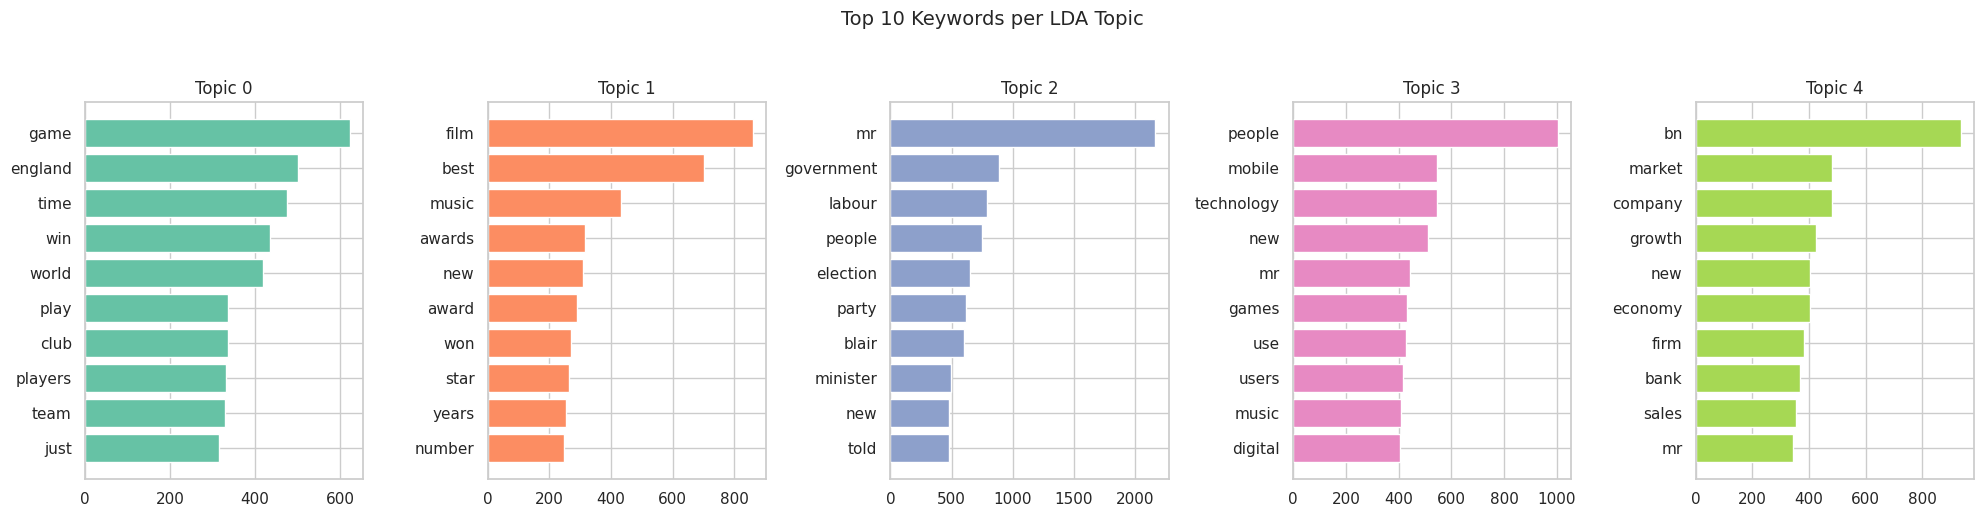

dominant_topic    0    1    2    3    4
category                               
business          0    1   22   12  475
entertainment     0  355   21    7    3
politics          0    0  408    1    8
sport           501    4    6    0    0
tech              4    6   13  372    6


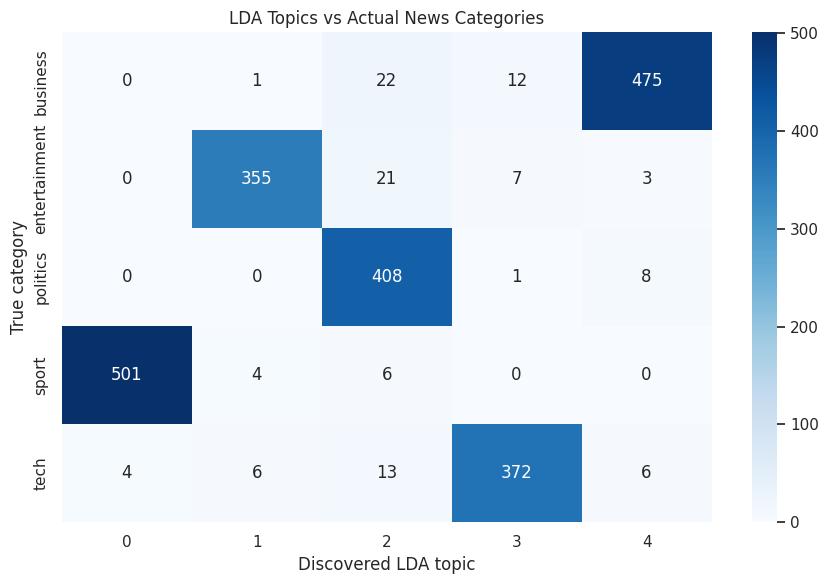

Share of each category on its dominant topic:
category
business         0.93
entertainment    0.92
politics         0.98
sport            0.98
tech             0.93
dtype: float64
LDA perplexity: 1875.2
LDA log-likelihood: -2710301


In [4]:

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
def basic_clean(t):
    t = re.sub(r'[^a-z\s]', ' ', str(t).lower())
    return re.sub(r'\s+', ' ', t).strip()
df['clean'] = df['text'].apply(basic_clean)
count_vec = CountVectorizer(stop_words='english', min_df=5, max_df=0.5, max_features=5000)
X_counts = count_vec.fit_transform(df['clean'])
print('Document-term matrix:', X_counts.shape)
N_TOPICS = 5
lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=RANDOM_STATE, learning_method='batch', max_iter=20)
lda.fit(X_counts)
feature_names = np.array(count_vec.get_feature_names_out())
for k, comp in enumerate(lda.components_):
    top_idx = comp.argsort()[::-1][:10]
    print('Topic', k, ':', ', '.join(feature_names[top_idx]))
fig, axes = plt.subplots(1, N_TOPICS, figsize=(20, 5))
for k, ax in enumerate(axes):
    comp = lda.components_[k]
    top_idx = comp.argsort()[::-1][:10]
    ax.barh(feature_names[top_idx][::-1], comp[top_idx][::-1], color=sns.color_palette('Set2')[k])
    ax.set_title('Topic ' + str(k))
plt.suptitle('Top 10 Keywords per LDA Topic', y=1.03, fontsize=14)
plt.tight_layout()
plt.savefig('topic_keywords.png', dpi=110, bbox_inches='tight')
plt.show()
doc_topics = lda.transform(X_counts)
df['dominant_topic'] = doc_topics.argmax(axis=1)
cross = pd.crosstab(df['category'], df['dominant_topic'])
print(cross)
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(cross, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('LDA Topics vs Actual News Categories')
ax.set_xlabel('Discovered LDA topic')
ax.set_ylabel('True category')
plt.tight_layout()
plt.savefig('topic_vs_category.png', dpi=110, bbox_inches='tight')
plt.show()
align = (cross.max(axis=1) / cross.sum(axis=1))
print('Share of each category on its dominant topic:')
print(align.round(2))
print('LDA perplexity: %.1f' % lda.perplexity(X_counts))
print('LDA log-likelihood: %.0f' % lda.score(X_counts))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/35 [00:00<?, ?it/s]

Embeddings: (2225, 384)
Transformer (MiniLM) + LR | Accuracy: 0.9730 | Macro-F1: 0.9725
TF-IDF + LR (baseline) | Accuracy: 0.9775 | Macro-F1: 0.9774
               precision    recall  f1-score   support

     business       0.99      0.92      0.95       102
entertainment       0.95      1.00      0.97        77
     politics       0.95      0.99      0.97        84
        sport       1.00      1.00      1.00       102
         tech       0.96      0.96      0.96        80

     accuracy                           0.97       445
    macro avg       0.97      0.97      0.97       445
 weighted avg       0.97      0.97      0.97       445



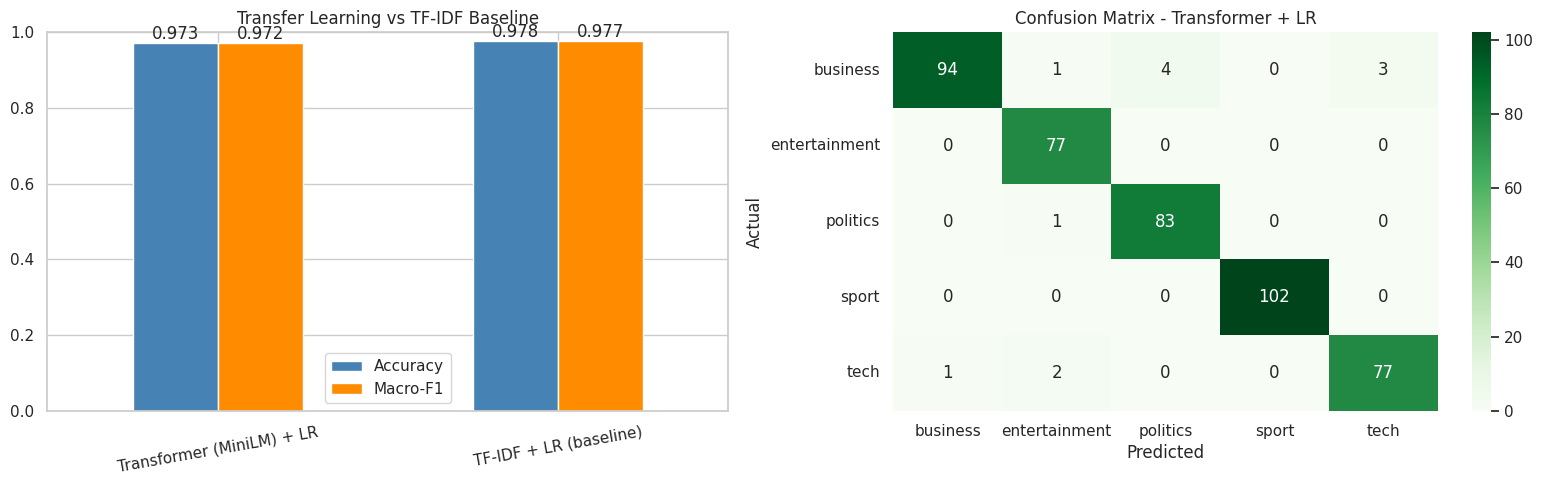

Best approach by macro-F1: TF-IDF + LR (baseline)
Saved bbc_classifier.joblib and week6_assets.zip


In [5]:

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import joblib, zipfile
y = df['category'].values
embedder = SentenceTransformer('all-MiniLM-L6-v2')
emb = embedder.encode(df['text'].str.slice(0, 2000).tolist(), batch_size=64, show_progress_bar=True)
print('Embeddings:', emb.shape)
idx = np.arange(len(df))
idx_tr, idx_te = train_test_split(idx, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
y_tr, y_te = y[idx_tr], y[idx_te]
clf_tf = LogisticRegression(max_iter=1000, C=10)
clf_tf.fit(emb[idx_tr], y_tr)
pred_tf = clf_tf.predict(emb[idx_te])
tfidf_pipe = Pipeline([('tfidf', TfidfVectorizer(stop_words='english', max_features=20000, ngram_range=(1, 2))), ('lr', LogisticRegression(max_iter=1000))])
tfidf_pipe.fit(df['clean'].values[idx_tr], y_tr)
pred_bl = tfidf_pipe.predict(df['clean'].values[idx_te])
results = {'Transformer (MiniLM) + LR': (accuracy_score(y_te, pred_tf), f1_score(y_te, pred_tf, average='macro')), 'TF-IDF + LR (baseline)': (accuracy_score(y_te, pred_bl), f1_score(y_te, pred_bl, average='macro'))}
for name, (a, f) in results.items():
    print(name, '| Accuracy: %.4f | Macro-F1: %.4f' % (a, f))
print(classification_report(y_te, pred_tf))
res_df = pd.DataFrame(results, index=['Accuracy', 'Macro-F1']).T
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
res_df.plot(kind='bar', ax=axes[0], color=['steelblue', 'darkorange'])
axes[0].set_title('Transfer Learning vs TF-IDF Baseline')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=10)
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='%.3f')
labels = sorted(df['category'].unique())
cm = confusion_matrix(y_te, pred_tf, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Confusion Matrix - Transformer + LR')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=110, bbox_inches='tight')
plt.show()
best_name = max(results, key=lambda k: results[k][1])
print('Best approach by macro-F1:', best_name)
if best_name.startswith('Transformer'):
    bundle = {'type': 'transfer', 'embedder_name': 'all-MiniLM-L6-v2', 'classifier': clf_tf, 'labels': labels}
else:
    bundle = {'type': 'tfidf', 'pipeline': tfidf_pipe, 'labels': labels}
joblib.dump(bundle, 'bbc_classifier.joblib', compress=3)
with zipfile.ZipFile('week6_assets.zip', 'w') as z:
    for f in ['category_distribution.png', 'entity_type_frequency.png', 'entity_by_category.png', 'topic_keywords.png', 'topic_vs_category.png', 'model_comparison.png', 'bbc_classifier.joblib']:
        if os.path.exists(f):
            z.write(f)
print('Saved bbc_classifier.joblib and week6_assets.zip')